In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# CIFAR-10 Dataset
The CIFAR-10 dataset comprises 60,000 color images, each of size 32x32 pixels. The dataset is segmented into 10 distinct classes, each representing a different object or creature. The classes encompass the following:

Airplane
Automobile
Bird
Cat
Deer
Dog
Frog
Horse
Ship
Truck
Each class has an equal number of images, totaling 6,000. From the total image count, 50,000 are designated for training while the remaining 10,000 are set aside for testing.

# Objectives
1. Data Insights and Exploration
Familiarize with the CIFAR-10 dataset. Visually inspect sample images from various classes to understand data    distribution.
2. Comprehensive Data Preprocessing
Normalize pixel values of the images to enhance model training efficiency.
Convert image labels into a one-hot encoded format suitable for classification tasks.
Implement data augmentation techniques to increase the dataset's variability and improve model generalization.
3. Architectural Design using Keras
Design a Convolutional Neural Network (CNN) tailored for the CIFAR-10 dataset using the Keras framework.
Incorporate mechanisms such as dropouts and regularizations to counteract overfitting.
4. Model Training Process
Train the CNN using the prepared dataset.
Utilize callbacks to adjust the learning rate dynamically and halt the training early if no improvements are detected, restoring the best model weights from the training.
5. Learning Analysis
Visualize the model's learning curves, observing both training and validation performance metrics over epochs.
6. Model Evaluation
Assess the trained model's accuracy and loss on the unseen test data to determine its robustness.
7. Real-world Generalization Check
Evaluate the model's predictive capability using an image not part of the CIFAR-10 dataset to gauge its real-world applicability.

   
   

# Import Necessary Libraries
First we need to import all necessary libraries required to start the project. For the environment, we are choosing TensorFlow and Keras to handle image data, craft our model, and optimize it for best performance.

In [1]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# General libraries
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical
from keras.models import Sequential

# For model portion
from keras.layers import Dense, Conv2D, MaxPooling2D
from keras.layers import Dropout, Flatten, BatchNormalization
from keras.regularizers import l2
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras.models import load_model


2026-06-25 19:40:01.772669: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782416401.798108     199 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782416401.806490     199 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782416401.826739     199 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782416401.826761     199 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782416401.826764     199 computation_placer.cc:177] computation placer alr

# Data Preparation 
First task is to load the dataset 

In [2]:
(X_train, y_train),(X_test, y_test)= cifar10.load_data()

Now we will split the dataset. As there are 60,000 images, we will likely split it to 45,000: 5,000: 10,000, corresponding to the train/dev/test split.

In [4]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.1, random_state=0)

lets print the set 

In [5]:
print('Train Images Shape:  ',X_train.shape)
print('Train labels Shape: ', y_train.shape)

print('\nValidation Images Shape: ', X_valid.shape)
print('Validation Labels Shape: ', y_valid.shape)

print('\nTest Images Shape:       ', X_test.shape)
print('Test Images Shape:          ', y_test.shape)

Train Images Shape:   (40500, 32, 32, 3)
Train labels Shape:  (40500, 1)

Validation Images Shape:  (4500, 32, 32, 3)
Validation Labels Shape:  (4500, 1)

Test Images Shape:        (10000, 32, 32, 3)
Test Images Shape:           (10000, 1)


Now lets visualize some images from the dataset

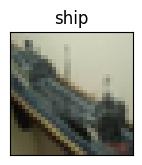

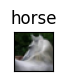

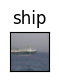

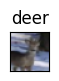

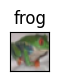

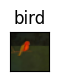

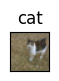

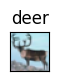

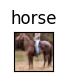

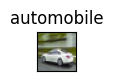

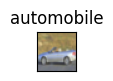

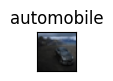

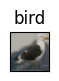

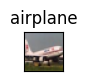

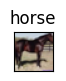

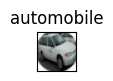

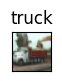

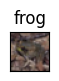

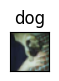

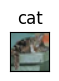

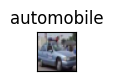

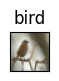

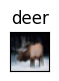

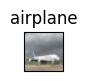

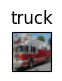

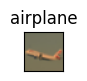

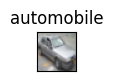

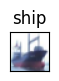

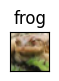

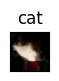

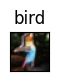

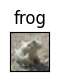

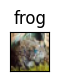

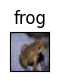

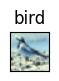

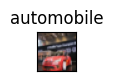

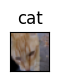

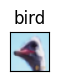

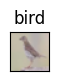

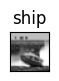

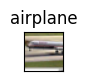

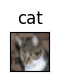

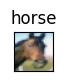

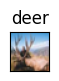

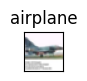

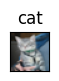

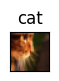

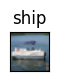

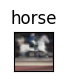

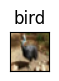

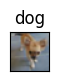

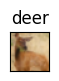

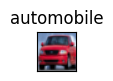

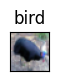

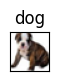

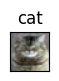

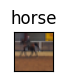

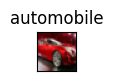

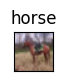

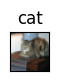

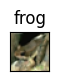

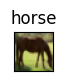

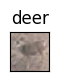

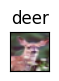

In [7]:
# CIFAR-10 classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# create a new figure
plt.figure(figsize=(15,15))

# Look over the first 25 images 
for i in range(64):
    # to plot each image as a subplot
    plt.subplot(8,8,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(True)
# Display the image 
    plt.imshow(X_train[i]) 
# Set the label as the title
    plt.title(class_names[y_train[i][0]], fontsize=12)
# Display the figure
    plt.show()


# Data Preprocessing
we undertake essential preparatory measures to ensure our dataset is aptly primed for the modeling process: Normalization of Image Data, One-Hot Encoding of Labels, Data Augmentation

# Normalization

In [8]:
# Convert pixel values data type to float32
X_train = X_train.astype('float32')
X_test  = X_test.astype('float32')
X_valid = X_valid.astype('float32')

# Calculate the mean and standard deviation of the training images
mean = np.mean(X_train)
std  = np.std(X_train)

# Normalize the data
# The tiny value 1e-7 is added to prevent division by zero
X_train = (X_train-mean)/(std+1e-7)
X_test  = (X_test-mean) /(std+1e-7)
X_valid = (X_valid-mean)/(std+1e-7)

# One-Hot Encoding of Labels

In [11]:
Y_train= to_categorical(y_train, 10)
Y_test= to_categorical(y_test, 10)
Y_valid= to_categorical(y_valid, 10)

# Data Augmentation

In [13]:
# Data Augmentation
data_generator= ImageDataGenerator(
    
    # Rotate images randomly by up to 15 degrees
    rotation_range=15,
    
    # Shift images horizontally by up to 12% of their width
    width_shift_range=0.12,
    
    # Shift images vertically by up to 12% of their height
    height_shift_range=0.12,
    
    # Randomly flip images horizontally
    horizontal_flip=True,
    
    # Zoom images in by up to 10%
    zoom_range=0.1,
    
    # Change brightness by up to 10%
    brightness_range=[0.9,1.1],

    # Shear intensity (shear angle in counter-clockwise direction in degrees)
    shear_range=10,
    
    # Channel shift intensity
    channel_shift_range=0.1,
)

# Define CNN Model Architecture

In [14]:
# Initialize a sequential model
model = Sequential()

# Set the weight decay value for L2 regularization
weight_decay = 0.0001

# Add the first convolutional layer with 32 filters of size 3x3
model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay), 
                 input_shape=X_train.shape[1:]))
# Add batch normalization layer
model.add(BatchNormalization())

# Add the second convolutional layer similar to the first
model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())

# Add the first max pooling layer with pool size of 2x2
model.add(MaxPooling2D(pool_size=(2, 2)))
# Add dropout layer with 0.2 dropout rate
model.add(Dropout(rate=0.2))

# Add the third and fourth convolutional layers with 64 filters
model.add(Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)))   
model.add(BatchNormalization())
model.add(Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())

# Add the second max pooling layer and increase dropout rate to 0.3
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.3))

# Add the fifth and sixth convolutional layers with 128 filters
model.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay))) 
model.add(BatchNormalization())
model.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())

# Add the third max pooling layer and increase dropout rate to 0.4
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.4))

# Add the seventh and eighth convolutional layers with 256 filters
model.add(Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay))) 
model.add(BatchNormalization())
model.add(Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())

# Add the fourth max pooling layer and increase dropout rate to 0.5
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.5))

# Flatten the tensor output from the previous layer
model.add(Flatten())

# Add a fully connected layer with softmax activation function for outputting class probabilities
model.add(Dense(10, activation='softmax'))

I0000 00:00:1782416573.840101     199 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782416573.845549     199 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
model.summary()


# Training the CNN Model

In [15]:
# Set the batch size for the training
batch_size = 64

# Set the maximum number of epochs for the training
epochs = 300

# Define the optimizer (Adam)
optimizer = Adam(learning_rate=0.0005)

# Compile the model with the defined optimizer, loss function, and metrics
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Add ReduceLROnPlateau callback
# Here, the learning rate will be reduced by half (factor=0.5) if no improvement in validation loss is observed for 10 epochs
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001)

# Add EarlyStopping callback
# Here, training will be stopped if no improvement in validation loss is observed for 40 epochs.
# The `restore_best_weights` parameter ensures that the model weights are reset to the values from the epoch
# with the best value of the monitored quantity (in this case, 'val_loss').
early_stopping = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=1)

# Fit the model on the training data, using the defined batch size and number of epochs
# The validation data is used to evaluate the model's performance during training
# The callbacks implemented are learning rate reduction when a plateau is reached in validation loss and
# stopping training early if no improvement is observed
model.fit(data_generator.flow(X_train, Y_train, batch_size=batch_size),
          epochs=epochs,
          validation_data=(X_valid, Y_valid),
          callbacks=[reduce_lr, early_stopping], 
          verbose=2)

Epoch 1/300


I0000 00:00:1782416592.563784     289 service.cc:152] XLA service 0x7a085c00dca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782416592.563867     289 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782416592.563880     289 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782416593.771120     289 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782416604.049111     289 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


633/633 - 72s - 114ms/step - accuracy: 0.3349 - loss: 2.3679 - val_accuracy: 0.4573 - val_loss: 1.6785 - learning_rate: 5.0000e-04
Epoch 2/300
633/633 - 42s - 66ms/step - accuracy: 0.4591 - loss: 1.7498 - val_accuracy: 0.5047 - val_loss: 1.6489 - learning_rate: 5.0000e-04
Epoch 3/300
633/633 - 42s - 66ms/step - accuracy: 0.5285 - loss: 1.4936 - val_accuracy: 0.5287 - val_loss: 1.5229 - learning_rate: 5.0000e-04
Epoch 4/300
633/633 - 42s - 66ms/step - accuracy: 0.5773 - loss: 1.3580 - val_accuracy: 0.6253 - val_loss: 1.1831 - learning_rate: 5.0000e-04
Epoch 5/300
633/633 - 42s - 66ms/step - accuracy: 0.6108 - loss: 1.2462 - val_accuracy: 0.6847 - val_loss: 1.0375 - learning_rate: 5.0000e-04
Epoch 6/300
633/633 - 42s - 67ms/step - accuracy: 0.6432 - loss: 1.1393 - val_accuracy: 0.6873 - val_loss: 1.0140 - learning_rate: 5.0000e-04
Epoch 7/300
633/633 - 42s - 66ms/step - accuracy: 0.6651 - loss: 1.0690 - val_accuracy: 0.6829 - val_loss: 1.0415 - learning_rate: 5.0000e-04
Epoch 8/300
633/6

# Visualizing the Learning Curves

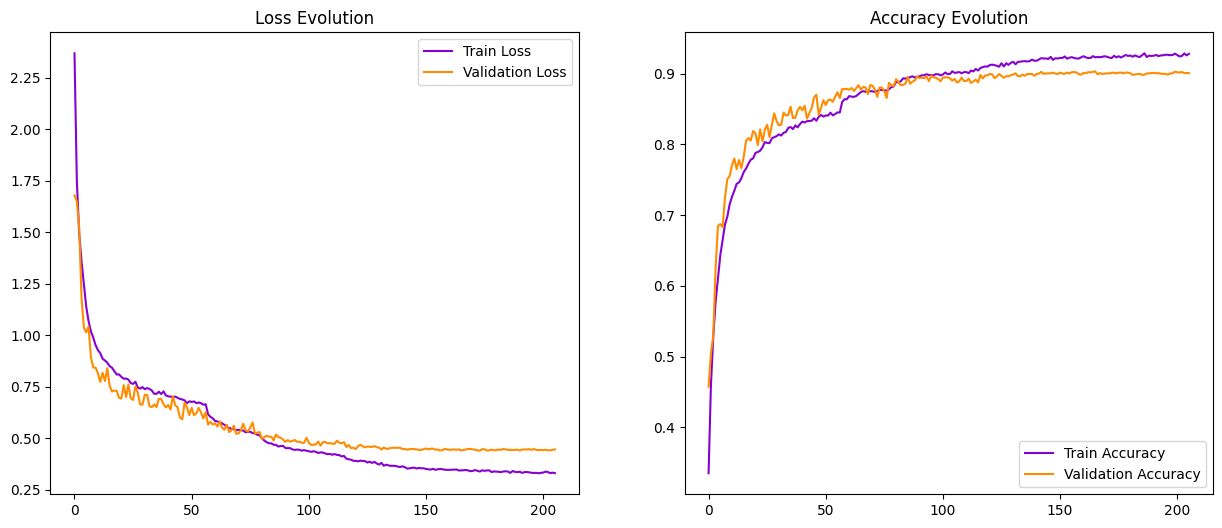

In [16]:
plt.figure(figsize=(15,6))

# Plotting the training and validation loss
plt.subplot(1, 2, 1)
plt.plot(model.history.history['loss'], label='Train Loss', color='#8502d1')
plt.plot(model.history.history['val_loss'], label='Validation Loss', color='darkorange')
plt.legend()
plt.title('Loss Evolution')

# Plotting the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(model.history.history['accuracy'], label='Train Accuracy', color='#8502d1')
plt.plot(model.history.history['val_accuracy'], label='Validation Accuracy', color='darkorange')
plt.legend()
plt.title('Accuracy Evolution')

plt.show()

# Evaluating the Optimal Model on Test Data

In [19]:
# Use the model to make predictions, evaluate on test data
test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=1)

print('\nTest Accuracy:', test_acc)
print('Test Loss:    ', test_loss )

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8994 - loss: 0.4536

Test Accuracy: 0.899399995803833
Test Loss:     0.45357176661491394


# Performance on an Out-of-Dataset Image

In [30]:
import os

print(os.listdir('/kaggle/input/datasets/drakon129/trukimagefortest'))

['truk.jfif']


Now lets load the image

(np.float64(-0.5), np.float64(298.5), np.float64(167.5), np.float64(-0.5))

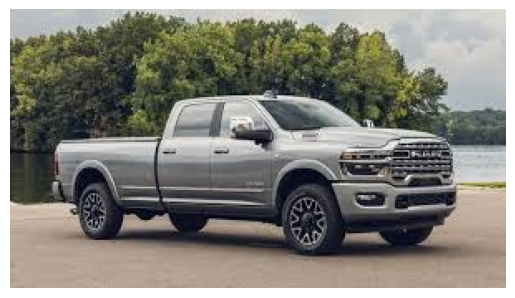

In [31]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('/kaggle/input/datasets/drakon129/trukimagefortest/truk.jfif')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis('off')

In [34]:
prediction = model.predict(image)

predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [35]:
print('Predicted class: ', class_names[predicted_class])

Predicted class:  automobile


As seen, the model correctly predicted this single desired image.